In [6]:
python_packages="pandas numpy matplotlib seaborn scikit-learn"
with open("requirements.txt", "w") as f:
    f.write(python_packages)
print("Done")

Done


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
age         0
sex         0
bmi         0
children    0
smoker      0
region     

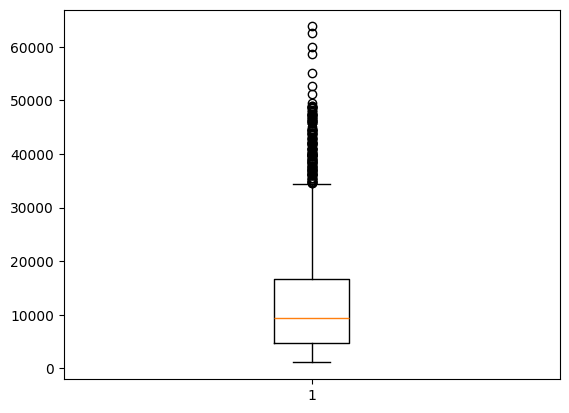

In [8]:


# Load the data and print the first 5 rows
df = pd.read_csv("/content/insurance.csv")
print(df.head())

# Check the shape: how many rows and columns?
print(df.shape)

# Inspect data types: use .info() — are any columns the wrong type? Fix at least 2
print(df.info())
df['age'] = df['age'].astype(int)
df['children'] = df['children'].astype(int)

# Find missing values: use .isnull().sum() — which columns have the most?
print(df.isnull().sum())

# Handle duplicates: check with .duplicated().sum() and remove if any
print(df.duplicated().sum())
df = df.drop_duplicates()

# Spot outliers: use a boxplot on the target column
plt.boxplot(df['charges'])
plt.show()

# Write a clean_data() function that:
# - fills missing values (choose mean / median / mode and explain why)
# - removes duplicates
# - clips or caps outliers (e.g. at 99th percentile)
# - returns the cleaned DataFrame
def clean_data(df):
    df['age'] = df['age'].fillna(df['age'].median())
    df['bmi'] = df['bmi'].fillna(df['bmi'].mean())
    df['children'] = df['children'].fillna(0)
    df = df.drop_duplicates()
    cap = df['charges'].quantile(0.99)
    df['charges'] = df['charges'].clip(upper=cap)
    return df

df = clean_data(df)

# Add 3 checks at the end
assert df.isnull().sum().sum() == 0
assert (df['charges'] > 0).all()
assert df.shape[1] == 7

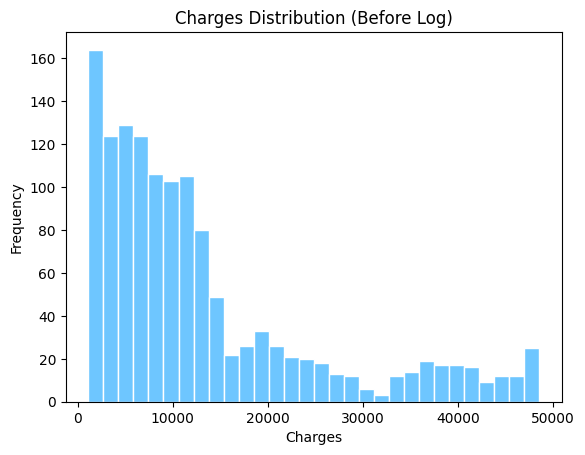

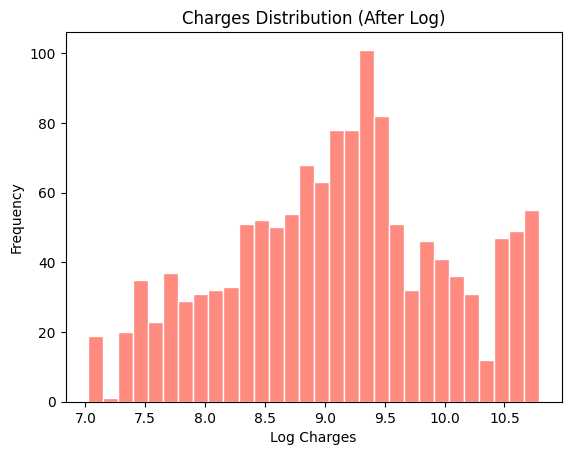

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# One-hot encode at least 2 categorical columns
df = pd.get_dummies(df, columns=['sex', 'region'], drop_first=True)

# Ordinal encode 1 ordered column
df['smoker'] = df['smoker'].map({'no': 0, 'yes': 1})

# Scale at least 2 numerical columns using StandardScaler
scaler = StandardScaler()
df[['age', 'bmi']] = scaler.fit_transform(df[['age', 'bmi']])

# Create 2 domain features using safe division
df['charges_per_child'] = df['charges'] / (df['children'] + 1)
df['bmi_per_age'] = df['bmi'] / (df['age'] + 1)

# Create 1 interaction feature
df['age_bmi'] = df['age'] * df['bmi']

# Log-transform 1 skewed column and show histogram before and after
plt.hist(df['charges'], bins=30, color='#6EC6FF', edgecolor='white')
plt.title("Charges Distribution (Before Log)")
plt.xlabel("Charges")
plt.ylabel("Frequency")
plt.show()

df['charges_log'] = np.log1p(df['charges'])

plt.hist(df['charges_log'], bins=30, color='#FF8A80', edgecolor='white')
plt.title("Charges Distribution (After Log)")
plt.xlabel("Log Charges")
plt.ylabel("Frequency")
plt.show()

# Bin 1 column into meaningful groups
df['age_group'] = pd.cut(df['age'], bins=3, labels=['Young', 'Middle', 'Old'])

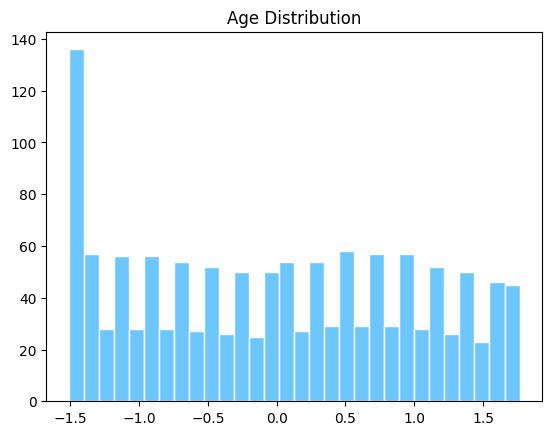

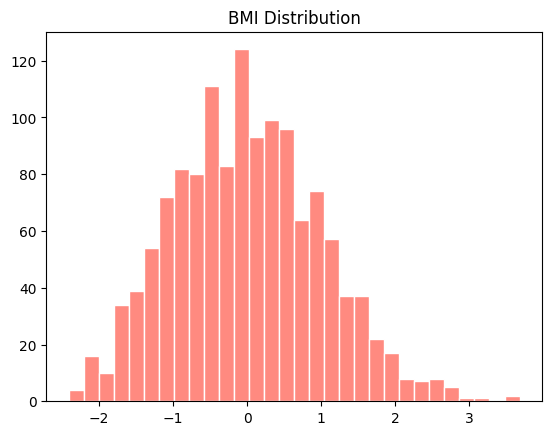

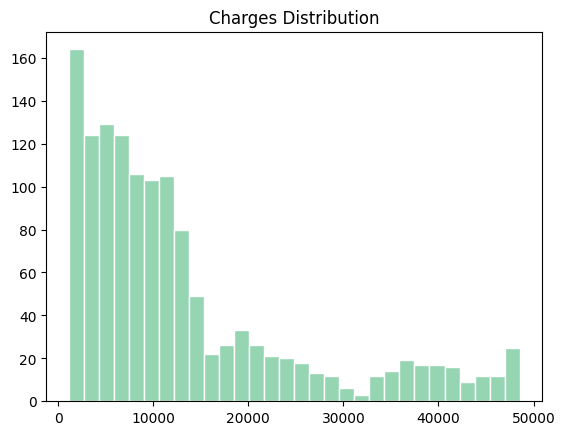

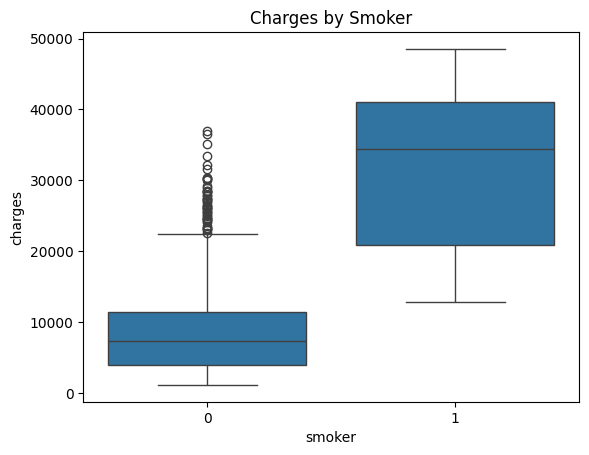

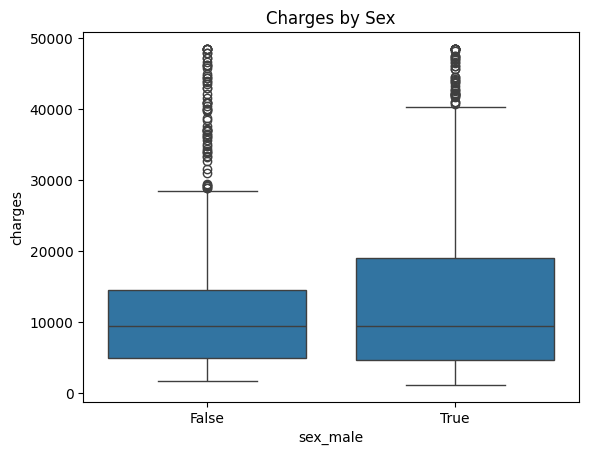

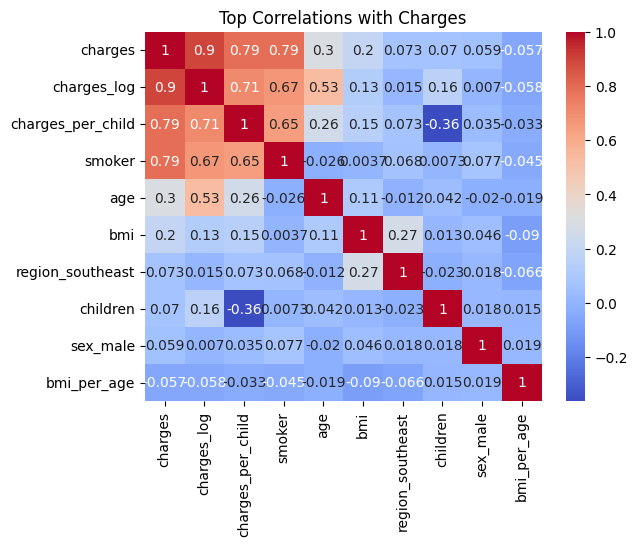

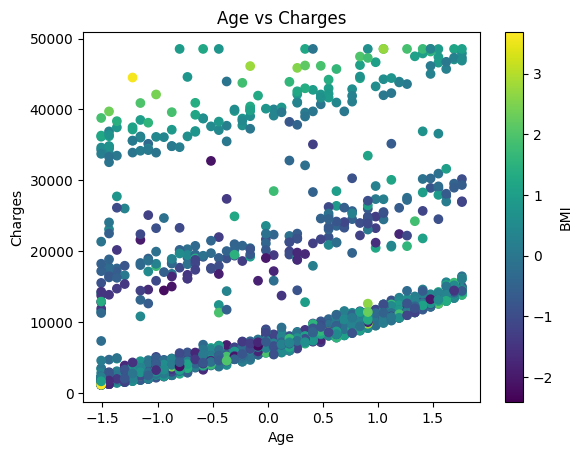

smoker
0     8440.660307
1    31807.519571
Name: charges, dtype: float64
sex_male
False    12520.488956
True     13924.620118
Name: charges, dtype: float64
Age distribution: Age values are spread across the dataset without extreme concentration in one age.
BMI distribution: BMI values are concentrated around the middle range, with fewer extreme values.
Charges distribution: Charges are right-skewed, meaning most people have lower charges and fewer people have very high charges.
Charges by smoker: Smokers generally have higher charges than non-smokers.
Charges by sex: The difference in charges by sex is smaller than the difference by smoker status.
Correlation heatmap: The heatmap highlights which numerical variables are most strongly related to charges.
Scatter plot: The scatter plot shows the relationship between age and charges, with BMI adding extra context.
Mean: 13229.380903755422
Standard Deviation: 11937.109835237112
[-0.45315959  0.50942165  0.3831546  -1.30505219 -0.29245608]


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from numpy.linalg import norm
from sklearn.preprocessing import StandardScaler

# Histograms / KDE: plot distributions of at least 3 numerical features — describe the shape
plt.hist(df['age'], bins=30, color='#6EC6FF', edgecolor='white')
plt.title("Age Distribution")
plt.show()

plt.hist(df['bmi'], bins=30, color='#FF8A80', edgecolor='white')
plt.title("BMI Distribution")
plt.show()

plt.hist(df['charges'], bins=30, color='#95D5B2', edgecolor='white')
plt.title("Charges Distribution")
plt.show()

# Grouped boxplots: compare the target across at least 2 categories
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Charges by Smoker")
plt.show()

sex_col = 'sex_male' if 'sex_male' in df.columns else 'sex'
sns.boxplot(x=sex_col, y='charges', data=df)
plt.title("Charges by Sex")
plt.show()

# Correlation heatmap: show the top 10 features most correlated with the target
corr_target = df.corr(numeric_only=True)['charges'].abs().sort_values(ascending=False).head(10)
top_features = corr_target.index
corr_matrix = df[top_features].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Top Correlations with Charges")
plt.show()

# Scatter plot: plot a key relationship with colour for a third variable
scatter = plt.scatter(df['age'], df['charges'], c=df['bmi'], cmap='viridis')
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Age vs Charges")
plt.colorbar(scatter, label='BMI')
plt.show()

# Groupby summary: compute mean target by a category — which group is highest / lowest?
print(df.groupby('smoker')['charges'].mean())
print(df.groupby(sex_col)['charges'].mean())

# Write a 1-paragraph insight for each chart (what does it tell us?)
print("Age distribution: Age values are spread across the dataset without extreme concentration in one age.")
print("BMI distribution: BMI values are concentrated around the middle range, with fewer extreme values.")
print("Charges distribution: Charges are right-skewed, meaning most people have lower charges and fewer people have very high charges.")
print("Charges by smoker: Smokers generally have higher charges than non-smokers.")
print("Charges by sex: The difference in charges by sex is smaller than the difference by smoker status.")
print("Correlation heatmap: The heatmap highlights which numerical variables are most strongly related to charges.")
print("Scatter plot: The scatter plot shows the relationship between age and charges, with BMI adding extra context.")

# Compute the mean and standard deviation of the target manually using NumPy
target = df['charges'].values
mean_target = np.sum(target) / len(target)
std_target = np.sqrt(np.sum((target - mean_target) ** 2) / len(target))
print("Mean:", mean_target)
print("Standard Deviation:", std_target)

# Standardise one column by hand using broadcasting: z = (X - mean) / std — compare with StandardScaler output
x = df['bmi'].values
mean_x = np.sum(x) / len(x)
std_x = np.sqrt(np.sum((x - mean_x) ** 2) / len(x))
z_manual = (x - mean_x) / std_x

scaler = StandardScaler()
z_scaler = scaler.fit_transform(df[['bmi']]).flatten()

print(z_manual[:5])
print(z_scaler[:5])

# Compute cosine similarity between the feature vectors of the highest-value and lowest-value records
high = df.loc[df['charges'].idxmax(), ['age', 'bmi', 'children']].values
low = df.loc[df['charges'].idxmin(), ['age', 'bmi', 'children']].values
cos_sim = np.dot(high, low) / (norm(high) * norm(low))
print("Cosine similarity:", cos_sim)

# Estimate a probability: what fraction of items have a target above a certain threshold?
threshold = df['charges'].mean()
probability = (df['charges'] > threshold).sum() / len(df)
print("Probability:", probability)